<a href="https://colab.research.google.com/github/syafiatuladawiah77-tech/UTS_MECHINE-LEARNING/blob/main/ml_fikss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Analisis Perbandingan Algoritma XGBoost, Random Forest, dan Decion Tree dalam Klasifikasi Tingkat Pengalaman Profesional AI Berdasarkan Dimensi Kompensasi dan Kompetensi**

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [32]:
df = pd.read_csv("AI Job Market Dataset (2).csv")

df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


**EDA DAN PRAPROCESSING**

In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [34]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


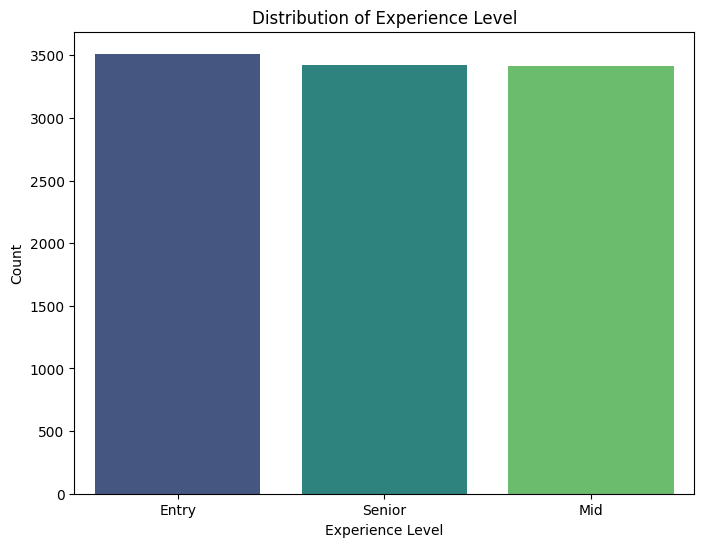

In [35]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='experience_level', palette='viridis', order=df['experience_level'].value_counts().index)
plt.title('Distribution of Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.show()

In [36]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


In [37]:
print(f"Jumlah duplikat dalam DataFrame: {df.duplicated().sum()}")

Jumlah duplikat dalam DataFrame: 0


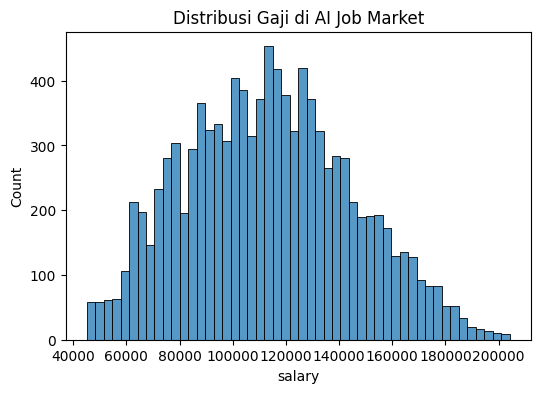

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df["salary"], bins=50)
plt.title("Distribusi Gaji di AI Job Market")
plt.show()

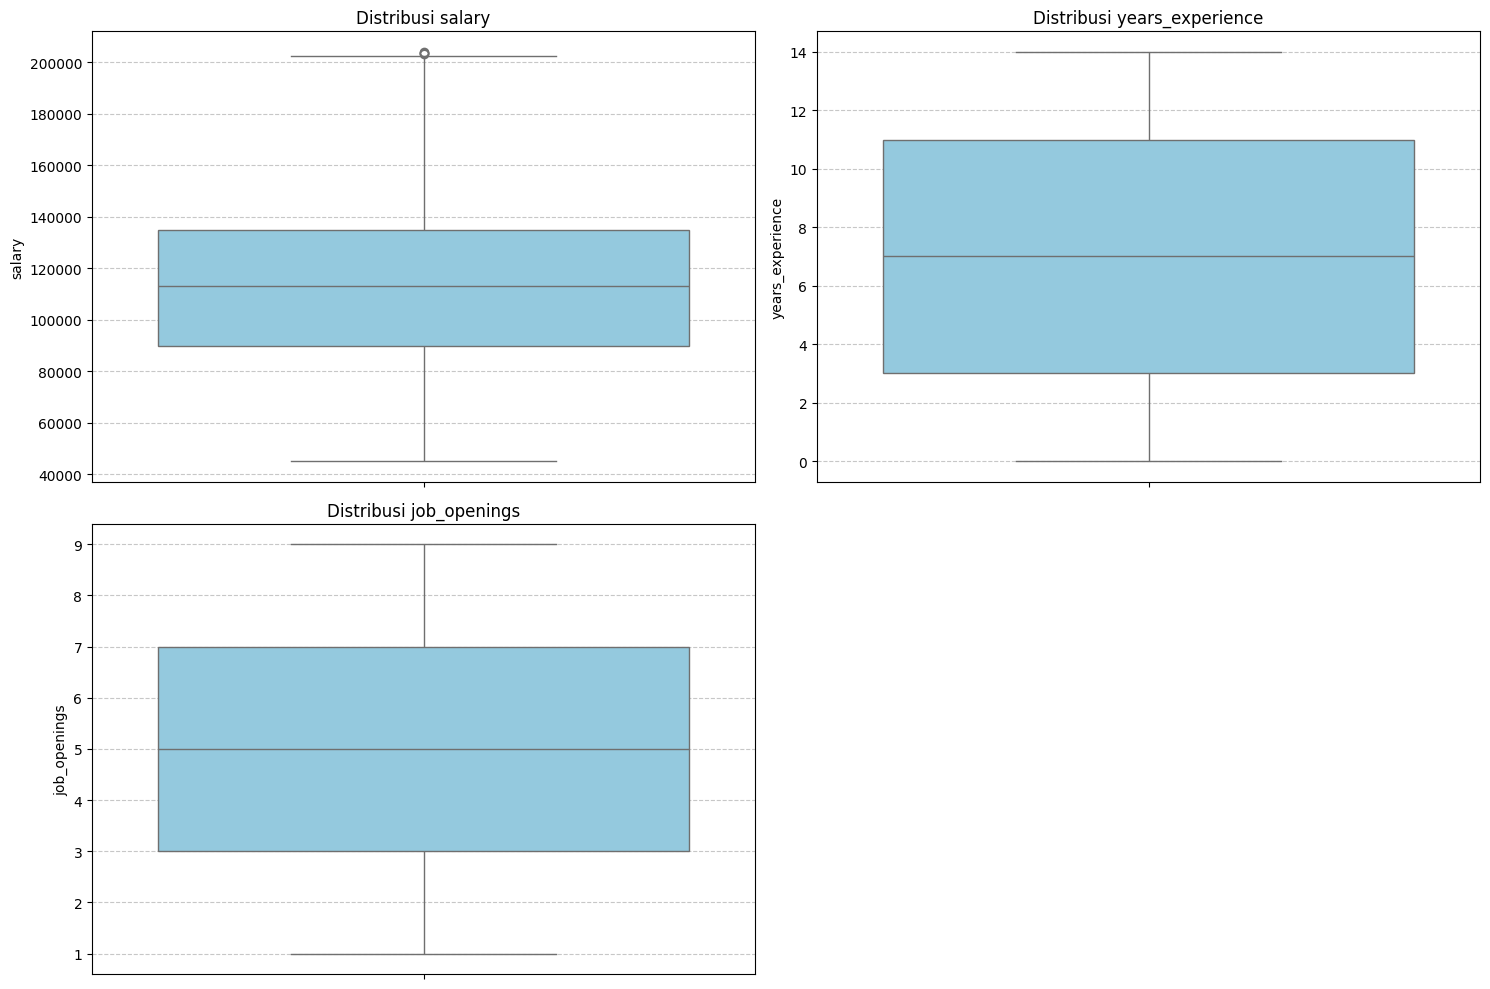

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tentukan kolom angka mana saja yang mau dibuatkan boxplot
# Saya sesuaikan dengan dataset AI Job kamu
numerical_cols = ['salary', 'years_experience', 'job_openings']

# 2. Atur ukuran bingkai (3 baris, 2 kolom agar muat semua)
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    # Membuat sub-plot (kotak) untuk setiap fitur
    plt.subplot(2, 2, i+1)

    # Gambar boxplot secara vertikal (y=col) agar rapi
    sns.boxplot(y=df[col], color='skyblue')

    plt.title(f'Distribusi {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Agar antar grafik tidak dempet-dempetan
plt.tight_layout()
plt.show()

In [40]:
df = df.drop(["job_id", "job_title"], axis=1)

In [41]:
from sklearn.preprocessing import LabelEncoder

# 1. Encoding Target
mapping = {"Entry": 0, "Mid": 1, "Senior": 2}
df["experience_level_encoded"] = df["experience_level"].map(mapping)

# 2. Simpan LabelEncoder per kolom ke dalam dictionary
label_encoders_dict = {}
df_encoded = df.copy()

# Ambil kolom kategorikal (teks) yang bukan target/ID/Skills
# Kolom skills tidak masuk sini karena tipenya sudah numerik (0/1)
categorical_cols = df_encoded.select_dtypes(include='object').columns
cols_to_encode = [col for col in categorical_cols if col not in ["experience_level", "job_id"]]

for col in cols_to_encode:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders_dict[col] = le # Inilah "Kamus" kita

print("✅ Kamus Encoder Berhasil Disimpan!")

✅ Kamus Encoder Berhasil Disimpan!


In [42]:
df_encoded.head()

,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings,experience_level_encoded
0,3,4,1,2,Senior,2,1,0,0,0,1,0,158322,6,2024,1,4,2
1,1,5,0,0,Mid,0,0,1,1,1,0,1,163666,11,2026,0,9,1
2,1,5,2,1,Mid,14,1,1,0,1,0,1,158556,3,2026,0,9,1
3,3,3,2,2,Mid,9,1,0,1,0,1,1,95775,3,2025,0,7,1
4,1,3,2,0,Mid,5,1,1,1,1,0,0,111873,12,2021,1,2,1


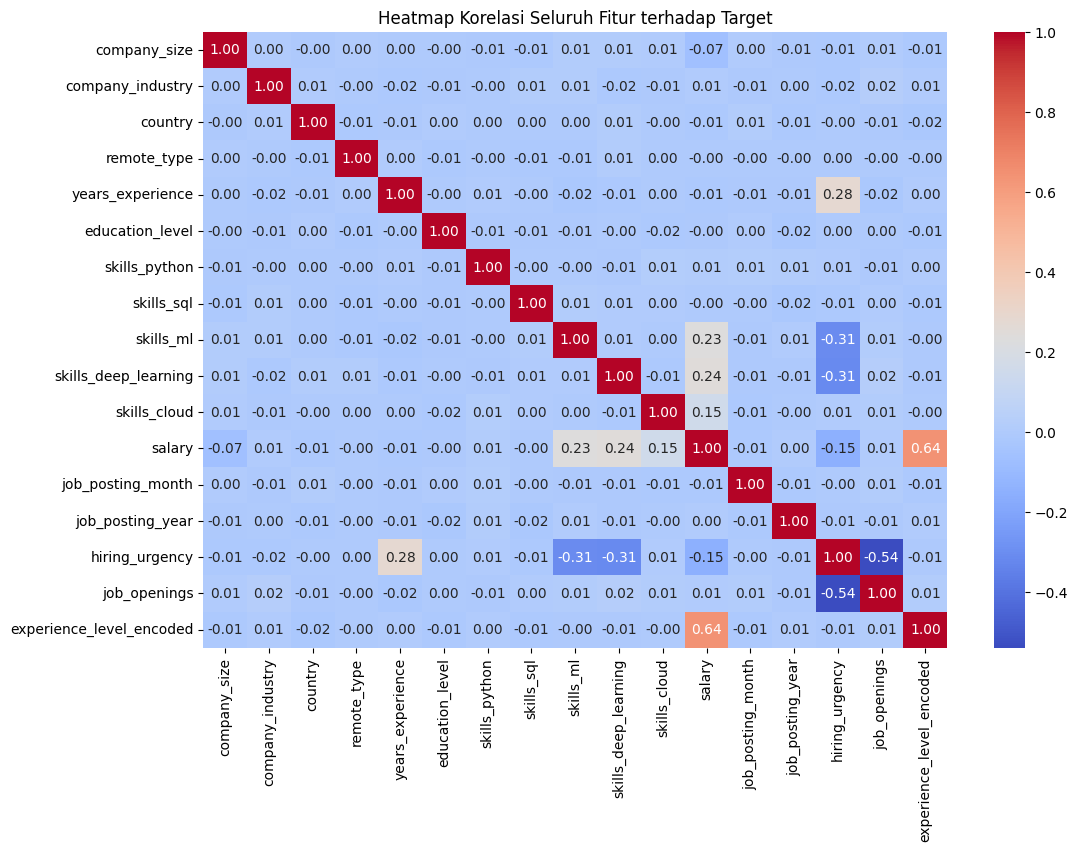

In [43]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap Korelasi Seluruh Fitur terhadap Target")
plt.show()

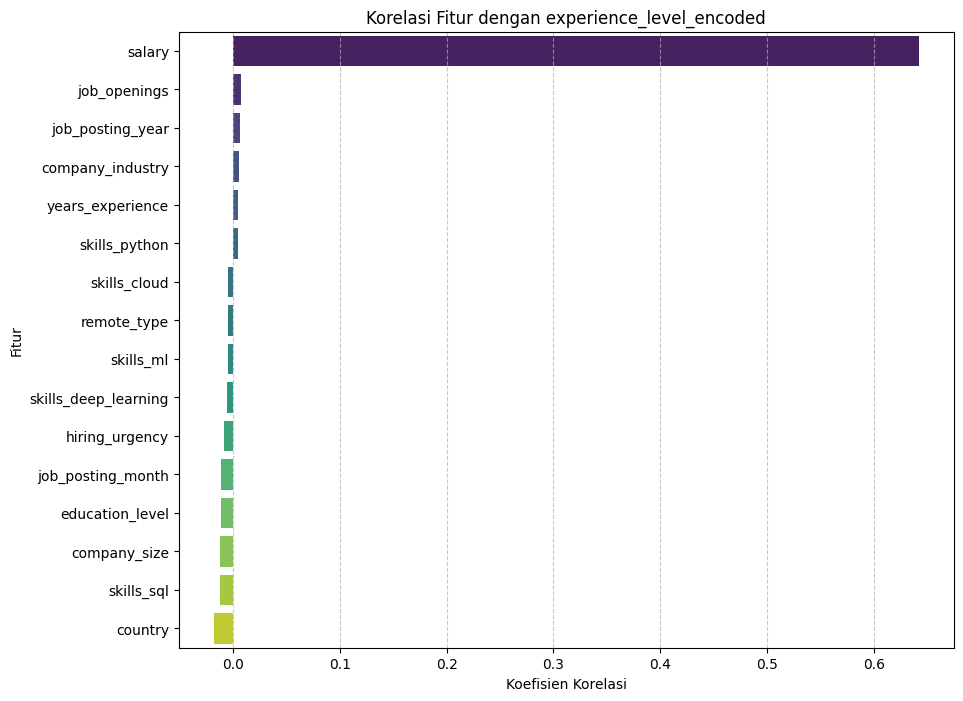

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with the target variable
correlations = df_encoded.corr(numeric_only=True)['experience_level_encoded'].sort_values(ascending=False)

# Drop the target itself from the correlation list
correlations = correlations.drop('experience_level_encoded')

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Korelasi Fitur dengan experience_level_encoded')
plt.xlabel('Koefisien Korelasi')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [46]:
# Tambahkan "job_id" dan "job_title" ke dalam daftar kolom yang dibuang (drop)
X = df_encoded.drop(["experience_level", "experience_level_encoded"], axis=1)
y = df_encoded["experience_level_encoded"]

print(f"Fitur yang digunakan: {X.columns.tolist()}")

Fitur yang digunakan: ['company_size', 'company_industry', 'country', 'remote_type', 'years_experience', 'education_level', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'hiring_urgency', 'job_openings']


**futere Enginering dan Model Selection**

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Definisikan Pipeline Dasar (Scaler + Placeholder Model)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier()) # Ini hanya tempat sementara
])

# 2. Definisikan Parameter (WAJIB pakai awalan 'model__' agar nyambung ke pipeline)
# 2. Definisikan Parameter dengan Perbaikan Recall (class_weight & n_estimators)
param_models = [
    {
        "model": [RandomForestClassifier(random_state=42, class_weight='balanced_subsample')],
        "model__n_estimators": [300, 500],
        "model__max_depth": [15, 20],
        "model__min_samples_split": [2, 5],
        "model__max_features": ['sqrt', 'log2']
    },
    {
        "model": [DecisionTreeClassifier(random_state=42, class_weight='balanced')],
        "model__max_depth": [5, 7, 10],
        "model__min_samples_split": [20, 50],
        "model__criterion": ["gini", "entropy"]
    },
    {
        "model": [XGBClassifier(eval_metric="mlogloss", random_state=42)],
        "model__n_estimators": [200], # Ditambah untuk mengejar akurasi 90%
        "model__max_depth": [4, 5],
        "model__learning_rate": [0.05, 0.1]
    }
]

splits = [0.3, 0.2, 0.1]
all_models_results = []

**Hyperparameter Tuning Dan Evaluasi**

In [48]:
for split in splits:
    print(f"\n" + "="*40)
    print(f"PROSES TEST SIZE : {split}")
    print("="*40)

    # 1. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42, stratify=y)

    # 2. Loop untuk mengeksekusi 3 Algoritma
    for p_grid in param_models:
        grid = GridSearchCV(pipeline, [p_grid], cv=5, n_jobs=-1, scoring='accuracy')

        # Proses Training (Scaling & Tuning jalan otomatis di dalam sini)
        grid.fit(X_train, y_train)

        # 3. Ambil Hasil Terbaik
        best_model = grid.best_estimator_
        model_name = type(best_model.named_steps["model"]).__name__

        # Prediksi (Otomatis pakai scaler yang sudah di-fit tadi)
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # Ambil metrik CV untuk tabel ranking
        mean_score = grid.cv_results_['mean_test_score'][grid.best_index_]
        std_score = grid.cv_results_['std_test_score'][grid.best_index_]

        # Simpan semua data untuk tabel dan heatmap nanti
        all_models_results.append({
            "Model": model_name,
            "Split": split,
            "Accuracy_Test": acc,
            "Mean_CV_Score": mean_score,
            "Std_CV_Score": std_score,
            "Best_Params": grid.best_params_,
            "Fitted_Pipeline": best_model, # Store the fitted pipeline here
            "y_test": y_test,
            "y_pred": y_pred
        })
        print(f"Selesai Tuning: {model_name} | Acc: {acc:.4f}")

print("\n✅ EKSPERIMEN SELESAI DENGAN PIPELINE!")


PROSES TEST SIZE : 0.3
Selesai Tuning: RandomForestClassifier | Acc: 0.8025
Selesai Tuning: DecisionTreeClassifier | Acc: 0.9691
Selesai Tuning: XGBClassifier | Acc: 0.8386

PROSES TEST SIZE : 0.2
Selesai Tuning: RandomForestClassifier | Acc: 0.8284
Selesai Tuning: DecisionTreeClassifier | Acc: 0.9710
Selesai Tuning: XGBClassifier | Acc: 0.8255

PROSES TEST SIZE : 0.1
Selesai Tuning: RandomForestClassifier | Acc: 0.8338
Selesai Tuning: DecisionTreeClassifier | Acc: 0.9662
Selesai Tuning: XGBClassifier | Acc: 0.8560

✅ EKSPERIMEN SELESAI DENGAN PIPELINE!



LAPORAN: RandomForestClassifier | TEST SIZE: 0.3
Accuracy Test: 0.8025
Mean CV Score: 0.7926 (+/- 0.0157)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      1054
           1       0.82      0.66      0.73      1024
           2       0.70      0.99      0.82      1026

    accuracy                           0.80      3104
   macro avg       0.83      0.80      0.80      3104
weighted avg       0.83      0.80      0.80      3104



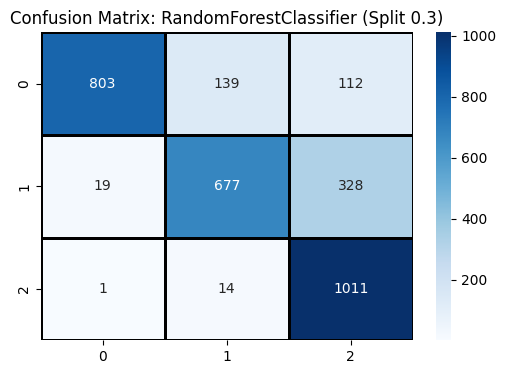


LAPORAN: DecisionTreeClassifier | TEST SIZE: 0.3
Accuracy Test: 0.9691
Mean CV Score: 0.9605 (+/- 0.0099)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1054
           1       0.96      0.96      0.96      1024
           2       0.96      0.98      0.97      1026

    accuracy                           0.97      3104
   macro avg       0.97      0.97      0.97      3104
weighted avg       0.97      0.97      0.97      3104



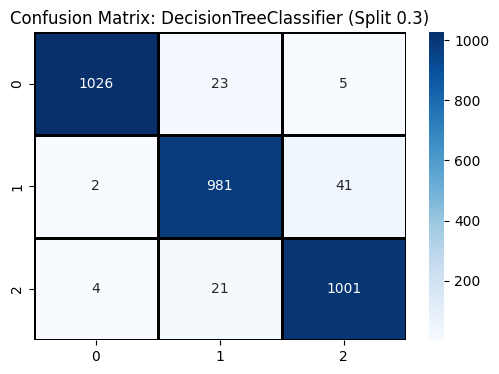


LAPORAN: XGBClassifier | TEST SIZE: 0.3
Accuracy Test: 0.8386
Mean CV Score: 0.8205 (+/- 0.0139)

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1054
           1       0.78      0.77      0.77      1024
           2       0.82      0.94      0.88      1026

    accuracy                           0.84      3104
   macro avg       0.84      0.84      0.84      3104
weighted avg       0.84      0.84      0.84      3104



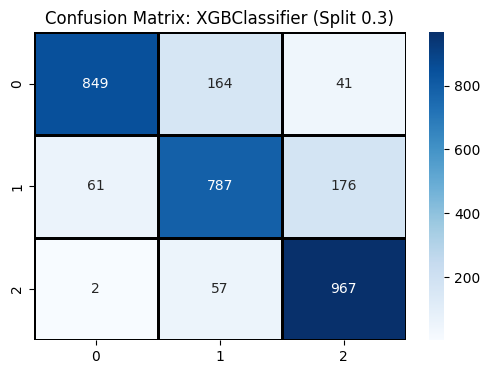


LAPORAN: RandomForestClassifier | TEST SIZE: 0.2
Accuracy Test: 0.8284
Mean CV Score: 0.8047 (+/- 0.0074)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       703
           1       0.87      0.68      0.76       682
           2       0.71      0.99      0.83       684

    accuracy                           0.83      2069
   macro avg       0.85      0.83      0.83      2069
weighted avg       0.86      0.83      0.83      2069



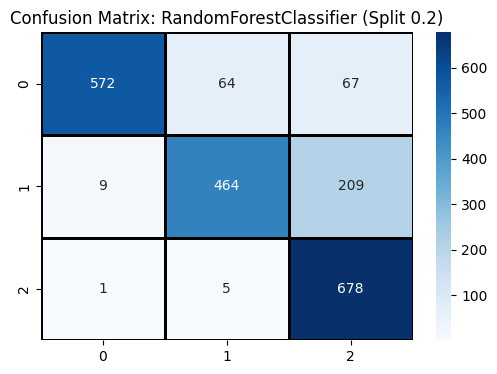


LAPORAN: DecisionTreeClassifier | TEST SIZE: 0.2
Accuracy Test: 0.9710
Mean CV Score: 0.9658 (+/- 0.0063)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       703
           1       0.98      0.96      0.97       682
           2       0.94      0.98      0.96       684

    accuracy                           0.97      2069
   macro avg       0.97      0.97      0.97      2069
weighted avg       0.97      0.97      0.97      2069



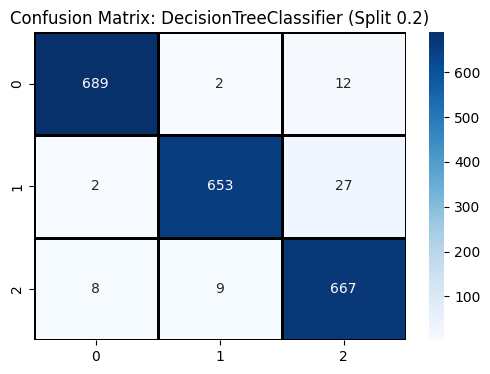


LAPORAN: XGBClassifier | TEST SIZE: 0.2
Accuracy Test: 0.8255
Mean CV Score: 0.8403 (+/- 0.0107)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       703
           1       0.76      0.74      0.75       682
           2       0.79      0.92      0.85       684

    accuracy                           0.83      2069
   macro avg       0.83      0.83      0.82      2069
weighted avg       0.83      0.83      0.83      2069



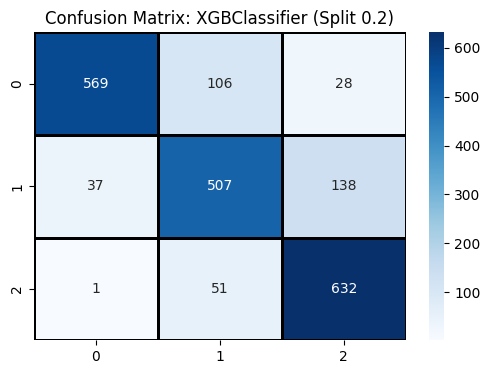


LAPORAN: RandomForestClassifier | TEST SIZE: 0.1
Accuracy Test: 0.8338
Mean CV Score: 0.8237 (+/- 0.0103)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       352
           1       0.87      0.69      0.77       341
           2       0.71      0.98      0.83       342

    accuracy                           0.83      1035
   macro avg       0.86      0.83      0.83      1035
weighted avg       0.86      0.83      0.83      1035



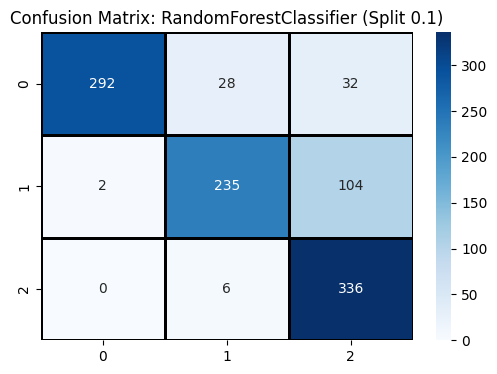


LAPORAN: DecisionTreeClassifier | TEST SIZE: 0.1
Accuracy Test: 0.9662
Mean CV Score: 0.9750 (+/- 0.0067)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       352
           1       0.97      0.96      0.97       341
           2       0.95      0.96      0.95       342

    accuracy                           0.97      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



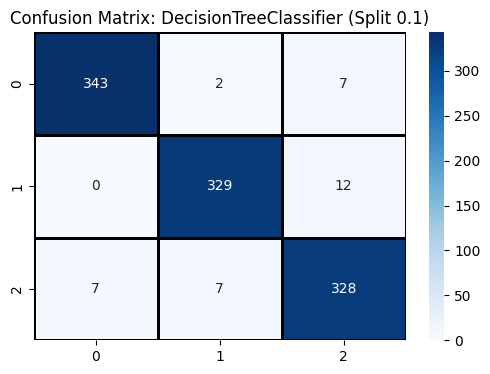


LAPORAN: XGBClassifier | TEST SIZE: 0.1
Accuracy Test: 0.8560
Mean CV Score: 0.8310 (+/- 0.0213)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.92       352
           1       0.82      0.76      0.79       341
           2       0.80      0.93      0.86       342

    accuracy                           0.86      1035
   macro avg       0.86      0.86      0.86      1035
weighted avg       0.86      0.86      0.86      1035



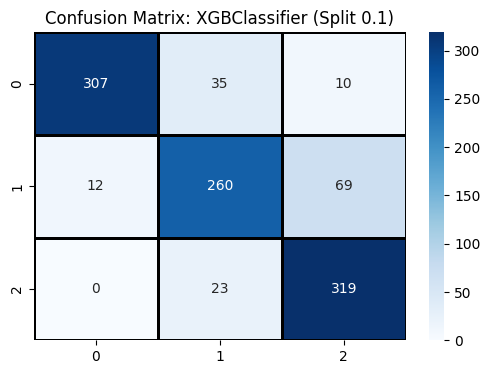

In [49]:
for res in all_models_results:
    print("\n" + "="*60)
    print(f"LAPORAN: {res['Model']} | TEST SIZE: {res['Split']}")
    print("="*60)

    print(f"Accuracy Test: {res['Accuracy_Test']:.4f}")
    print(f"Mean CV Score: {res['Mean_CV_Score']:.4f} (+/- {res['Std_CV_Score']:.4f})")

    print("\nClassification Report:")
    print(classification_report(res['y_test'], res['y_pred']))

    # Heatmap besar per model
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black')
    plt.title(f"Confusion Matrix: {res['Model']} (Split {res['Split']})")
    plt.show()

**Daftar Peringkat Model**

In [50]:
df_ranking_final = pd.DataFrame(all_models_results)

# Urutkan berdasarkan Accuracy Test tertinggi (Peringkat 1-9)
df_ranking_final = df_ranking_final.sort_values(by="Accuracy_Test", ascending=False).reset_index(drop=True)
df_ranking_final.index += 1 # Rank mulai dari 1

print("=== DAFTAR PERINGKAT SEMUA MODEL & SPLIT ===")
display(df_ranking_final[["Model", "Split", "Accuracy_Test", "Mean_CV_Score", "Std_CV_Score", "Best_Params", "Fitted_Pipeline"]])

=== DAFTAR PERINGKAT SEMUA MODEL & SPLIT ===


,Model,Split,Accuracy_Test,Mean_CV_Score,Std_CV_Score,Best_Params,Fitted_Pipeline
1,DecisionTreeClassifier,0.2,0.971000,0.965805,0.006262,{'model': DecisionTreeClassifier(class_weight=...,"(StandardScaler(), DecisionTreeClassifier(clas..."
2,DecisionTreeClassifier,0.3,0.969072,0.960501,0.009882,{'model': DecisionTreeClassifier(class_weight=...,"(StandardScaler(), DecisionTreeClassifier(clas..."
3,DecisionTreeClassifier,0.1,0.966184,0.974973,0.006722,{'model': DecisionTreeClassifier(class_weight=...,"(StandardScaler(), DecisionTreeClassifier(clas..."
4,XGBClassifier,0.1,0.856039,0.831042,0.021338,"{'model': XGBClassifier(base_score=None, boost...","(StandardScaler(), XGBClassifier(base_score=No..."
5,XGBClassifier,0.3,0.838595,0.820468,0.013927,"{'model': XGBClassifier(base_score=None, boost...","(StandardScaler(), XGBClassifier(base_score=No..."
6,RandomForestClassifier,0.1,0.833816,0.823738,0.010254,{'model': RandomForestClassifier(class_weight=...,"(StandardScaler(), (DecisionTreeClassifier(max..."
7,RandomForestClassifier,0.2,0.828420,0.804736,0.007449,{'model': RandomForestClassifier(class_weight=...,"(StandardScaler(), (DecisionTreeClassifier(max..."
8,XGBClassifier,0.2,0.825520,0.840260,0.010672,"{'model': XGBClassifier(base_score=None, boost...","(StandardScaler(), XGBClassifier(base_score=No..."
9,RandomForestClassifier,0.3,0.802513,0.792567,0.015726,{'model': RandomForestClassifier(class_weight=...,"(StandardScaler(), (DecisionTreeClassifier(max..."


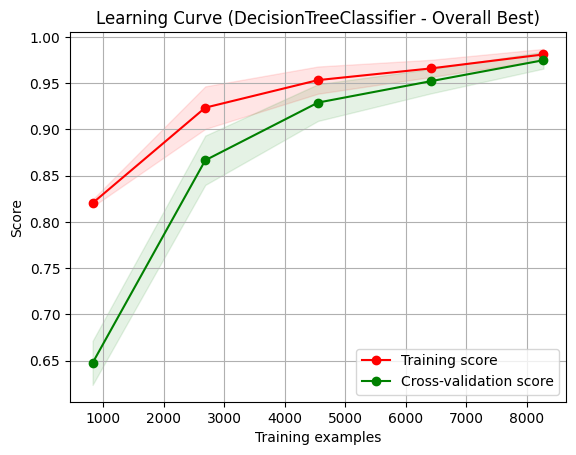

In [51]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# Get the overall best model from df_ranking_final (ranked 1st)
best_overall_model = df_ranking_final.loc[1, 'Fitted_Pipeline']

# Extract the name of the model from the pipeline
model_name = type(best_overall_model.named_steps['model']).__name__

title = f"Learning Curve ({model_name} - Overall Best)"

# Plot the learning curve using the full X and y for the best overall model
plot_learning_curve(best_overall_model, title, X, y, cv=5, n_jobs=-1)
plt.show()

**Inferences**

In [52]:
import pandas as pd
import numpy as np

# >>> TEMPAT INPUT DATA BARU <<<
input_user = {
    # 1. Fitur Numerik & Binary (Skills pakai 0 atau 1)
    'years_experience': 9,
    'salary': 95775,
    'skills_python':0 ,         # 1: Punya, 0: Tidak
    'skills_sql': 1,
    'skills_ml': 0,
    'skills_deep_learning': 1,
    'skills_cloud': 1,
    'job_openings': 7,
    'job_posting_month': 3,
    'job_posting_year': 2025,

    # 2. Fitur Kategorikal
    'company_size': 'Starup',    # Opsi: Startup, Medium, Enterprise, MNC
    'company_industry': 'Healthcare',
    'country': 'Austraia',
    'remote_type': 'Romate',     # Opsi: Remote, Hybrid, Onsite
    'hiring_urgency': 'hihg',    # Opsi: High, Medium, Low
    'education_level': 'Master'  # Opsi: Bachelor, Master, PhD
}


def proses_input_ke_angka(data, template_x, encoders):
    # Pinjam struktur kolom dari X
    row = template_x.iloc[[0]].copy()

    for col in row.columns:
        if col in data:
            val = data[col]
            # Jika kolom butuh diubah dari Teks ke Angka
            if col in encoders and isinstance(val, str):
                try:
                    row[col] = encoders[col].transform([val])[0]
                except:
                    # Jika user salah ketik, ambil kategori pertama dari data asli
                    row[col] = 0
            else:
                # Jika sudah angka (Salary/Skills), langsung masukkan
                row[col] = val
    return row

# --- EKSEKUSI PREDIKSI ---
# Ambil model terbaik dari hasil eksperimenmu
all_results_df = pd.DataFrame(all_models_results)
best_idx = all_results_df['Accuracy_Test'].idxmax()
model_final = all_models_results[best_idx]['Fitted_Pipeline']

# Jalankan transformasi dan prediksi
data_final = proses_input_ke_angka(input_user, X, label_encoders_dict)
prediksi_angka = model_final.predict(data_final)

# Tampilkan Hasil
mapping_target = {0: "Entry", 1: "Mid", 2: "Senior"}
print("\n" + "="*40)
print(f"HASIL PREDIKSI LEVEL: {mapping_target[prediksi_angka[0]]}")
print("="*40)


HASIL PREDIKSI LEVEL: Mid


In [53]:
import joblib
import pandas as pd

# Retrieve the best overall model from the previous analysis
# This assumes df_ranking_final and all_models_results are available from previous cell execution
if 'all_models_results' in locals() and len(all_models_results) > 0:
    all_results_df = pd.DataFrame(all_models_results)
    best_idx = all_results_df['Accuracy_Test'].idxmax()
    model_final = all_models_results[best_idx]['Fitted_Pipeline']

    # Save the entire best pipeline
    joblib.dump(model_final, "pipeline.pkl")
    print("Best model pipeline saved as pipeline.pkl")
else:
    print("Error: 'all_models_results' not found. Please run the model training and evaluation cells first.")

Best model pipeline saved as pipeline.pkl


In [54]:
from google.colab import files
files.download("pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
import joblib

joblib.dump(label_encoders_dict, "encoder_dict.pkl")

['encoder_dict.pkl']

In [57]:
from google.colab import files
files.download("encoder_dict.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>